# Hypothesis Verdict Synthesis: Cross-Experiment Evidence Mapping

**Evaluation artifact** that loads results from 4 upstream experiments (synthetic module recovery,
real benchmark, frustration meta-diagnostic, end-to-end pipeline) and produces definitive verdicts
for all 4 hypothesis success criteria:

- **SC1**: Synthetic Module Recovery (target Jaccard > 0.80)
- **SC2**: Real Benchmark Accuracy vs Random-Oblique
- **SC3**: Frustration-Oblique Correlation (target rho < 0, p < 0.05)
- **SC4**: Scalability (pipeline < 30 min)

Also includes reframed contribution claims, assumption validation, limitations catalogue,
and narrative arc for the paper's Discussion/Conclusion sections.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed -- all imports are pre-installed on Colab

# Core packages: pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')
    # scipy: 1.16.3 on Colab (Python 3.12+); use latest compatible for local Python
    try:
        _pip('scipy==1.16.3')
    except Exception:
        _pip('scipy')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


ERROR: Ignored the following versions that require a different python version: 1.16.0 Requires-Python >=3.11; 1.16.0rc1 Requires-Python >=3.11; 1.16.0rc2 Requires-Python >=3.11; 1.16.1 Requires-Python >=3.11; 1.16.2 Requires-Python >=3.11; 1.16.3 Requires-Python >=3.11; 1.17.0 Requires-Python >=3.11; 1.17.0rc1 Requires-Python >=3.11; 1.17.0rc2 Requires-Python >=3.11; 1.17.1 Requires-Python >=3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10
ERROR: Could not find a version that satisfies the requirement scipy==1.16.3 (from versions: 0.8.0, 0.9.0, 0.10.0, 0.10.1, 0.11.0, 0.12.0, 0.12.1, 0.13.0, 0.13.1, 0.13.2, 0.13.3, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.16.0, 0.16.1, 0.17.0, 0.17.1, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 1.0.0, 1.0.1, 1.1.0, 1.2.0, 1.2.1, 1.2.2, 1.2.3, 1.3.0, 1.3.1, 1.3.2, 1.3.3, 1.4.0, 1.4.1, 1.5.0, 1.5.1, 1.5.2, 1.5.3, 1.5.4, 1.6.0, 1.6.1, 1.7.2, 1.7.3, 1.8.0rc1, 1.8.0rc2, 1.8.0rc3, 1


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import sys
from collections import defaultdict

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/evaluation_iter6_hypothesis_verd/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded evaluation data: {data['metadata']['evaluation_name']}")
print(f"Experiments analyzed: {len(data['metadata']['experiments_analyzed'])}")
print(f"Datasets: {[d['dataset'] for d in data['datasets']]}")
print(f"Total examples: {sum(len(d['examples']) for d in data['datasets'])}")

Loaded evaluation data: hypothesis_verdict_synthesis
Experiments analyzed: 4
Datasets: ['sc1_synthetic_module_recovery', 'sc2_real_benchmark_accuracy', 'sc3_frustration_correlation', 'sc4_scalability', 'contribution_claims', 'assumption_validation', 'limitations_and_future_work', 'narrative_arc']
Total examples: 24


In [5]:
# ── Configuration ──────────────────────────────────────────────────────────
# Tunable parameters from original eval.py

# SC1: Synthetic Module Recovery
SC1_JACCARD_TARGET = 0.80          # Target Jaccard threshold for CONFIRMED
SC1_PARTIAL_THRESHOLD = 0.50       # Threshold for PARTIALLY_CONFIRMED
SC1_MIN_VARIANTS_ABOVE_080 = 2     # Min variants with Jaccard >= 0.80

# SC2: Real Benchmark Accuracy
PRIMARY_MAX_SPLITS = 10            # Primary max_splits value for comparison
SIGNIFICANCE_ALPHA = 0.05          # Significance level for statistical tests

# SC3: Frustration Correlation
SC3_ALPHA = 0.05                   # Alpha for correlation significance
SC3_PARTIAL_ALPHA = 0.10           # Alpha for partial confirmation

# SC4: Scalability
SCALABILITY_THRESHOLD_S = 1800.0   # 30 minutes in seconds

# Power analysis constants
Z_ALPHA = 1.96                     # z for alpha=0.05 two-sided
Z_BETA = 0.84                      # z for power=0.80

## Helper Functions

Utility functions from the original evaluation script: safe float conversion and
Wilcoxon signed-rank test with edge-case handling.

In [6]:
def safe_float(v, default: float = 0.0) -> float:
    """Convert to float, replacing None/NaN with default."""
    if v is None:
        return default
    try:
        f = float(v)
        return default if math.isnan(f) else f
    except (TypeError, ValueError):
        return default


def wilcoxon_safe(diffs: list, alternative: str = "two-sided") -> tuple:
    """Wilcoxon signed-rank test with edge-case handling."""
    nonzero = [d for d in diffs if abs(d) > 1e-12]
    if len(nonzero) < 3:
        n_pos = sum(1 for d in nonzero if d > 0)
        n_tot = len(nonzero)
        if n_tot == 0:
            return 0.0, 1.0
        result = stats.binomtest(n_pos, n_tot, 0.5, alternative=alternative)
        return float(n_pos), float(result.pvalue)
    try:
        stat, p = stats.wilcoxon(nonzero, alternative=alternative)
        return float(stat), float(p)
    except Exception:
        n_pos = sum(1 for d in nonzero if d > 0)
        n_tot = len(nonzero)
        if n_tot == 0:
            return 0.0, 1.0
        result = stats.binomtest(n_pos, n_tot, 0.5, alternative=alternative)
        return float(n_pos), float(result.pvalue)


def get_dataset_examples(data, dataset_name):
    """Extract examples for a given dataset from loaded data."""
    for ds in data["datasets"]:
        if ds["dataset"] == dataset_name:
            return ds["examples"]
    return []

## SC1: Synthetic Module Recovery (Jaccard > 0.80)

Evaluates whether SPONGE oracle spectral clustering on Co-Information graphs
recovers planted synergistic modules with Jaccard > 0.80 across synthetic variants.
Compares SPONGE oracle, auto-k, hard threshold, unsigned spectral, and random partition.

In [7]:
# ── SC1: Synthetic Module Recovery ──
sc1_examples = get_dataset_examples(data, "sc1_synthetic_module_recovery")
print(f"SC1: {len(sc1_examples)} synthetic variants\n")

# Per-variant Jaccard scores
METHODS_SC1 = ["sponge_oracle", "sponge_auto", "hard_threshold", "unsigned_spectral", "random"]
method_jaccards = {m: [] for m in METHODS_SC1}

for ex in sc1_examples:
    inp = json.loads(ex["input"])
    print(f"  Variant: {inp['variant']} (d={inp['n_features']}, n={inp['n_samples']}, k={inp['gt_n_modules']})")
    for m in METHODS_SC1:
        j = safe_float(ex.get(f"eval_{m}_jaccard"))
        method_jaccards[m].append(j)
        print(f"    {m:24s}  Jaccard = {j:.4f}")
    print()

# Mean Jaccard per method
print("Mean Jaccard per method (structured variants):")
for m in METHODS_SC1:
    mean_j = float(np.mean(method_jaccards[m])) if method_jaccards[m] else 0.0
    print(f"  {m:24s}  mean = {mean_j:.4f}")

# Variants with SPONGE oracle >= 0.80
above_080 = sum(1 for j in method_jaccards["sponge_oracle"] if j >= SC1_JACCARD_TARGET)
print(f"\nVariants with SPONGE-oracle Jaccard >= {SC1_JACCARD_TARGET}: {above_080}/{len(sc1_examples)}")

# Paired tests
diff_ht = [s - h for s, h in zip(method_jaccards["sponge_oracle"], method_jaccards["hard_threshold"])]
diff_un = [s - u for s, u in zip(method_jaccards["sponge_oracle"], method_jaccards["unsigned_spectral"])]
stat_ht, p_ht = wilcoxon_safe(diff_ht, alternative="greater")
stat_un, p_un = wilcoxon_safe(diff_un, alternative="greater")
print(f"SPONGE vs Hard Threshold:     stat={stat_ht:.3f}  p={p_ht:.4f}")
print(f"SPONGE vs Unsigned Spectral:  stat={stat_un:.3f}  p={p_un:.4f}")

# Verdict logic
sponge_mean = float(np.mean(method_jaccards["sponge_oracle"]))
if sponge_mean > SC1_JACCARD_TARGET and p_ht < SIGNIFICANCE_ALPHA and p_un < SIGNIFICANCE_ALPHA:
    sc1_verdict = "CONFIRMED"
elif sponge_mean > SC1_PARTIAL_THRESHOLD and (p_ht < SIGNIFICANCE_ALPHA or above_080 >= SC1_MIN_VARIANTS_ABOVE_080):
    sc1_verdict = "PARTIALLY_CONFIRMED"
else:
    sc1_verdict = "DISCONFIRMED"
print(f"\n>>> SC1 Verdict: {sc1_verdict}")

SC1: 3 synthetic variants

  Variant: easy_2mod_xor (d=10, n=10000, k=2)
    sponge_oracle             Jaccard = 1.0000
    sponge_auto               Jaccard = 1.0000
    hard_threshold            Jaccard = 1.0000
    unsigned_spectral         Jaccard = 1.0000
    random                    Jaccard = 0.0000

  Variant: medium_4mod_mixed (d=18, n=20000, k=4)
    sponge_oracle             Jaccard = 1.0000
    sponge_auto               Jaccard = 0.5000
    hard_threshold            Jaccard = 0.1429
    unsigned_spectral         Jaccard = 1.0000
    random                    Jaccard = 0.0000

  Variant: hard_4mod_unequal (d=31, n=20000, k=4)
    sponge_oracle             Jaccard = 0.3125
    sponge_auto               Jaccard = 0.2985
    hard_threshold            Jaccard = 0.1781
    unsigned_spectral         Jaccard = 0.4571
    random                    Jaccard = 0.1143

Mean Jaccard per method (structured variants):
  sponge_oracle             mean = 0.7708
  sponge_auto               me

## SC2: Real Benchmark Accuracy vs Random-Oblique

Compares signed spectral oblique splits against random oblique splits on real datasets.
Evaluates accuracy difference, arity difference, and win/loss/tie counts per (dataset, max_splits).

In [8]:
# ── SC2: Real Benchmark Accuracy ──
sc2_examples = get_dataset_examples(data, "sc2_real_benchmark_accuracy")
print(f"SC2: {len(sc2_examples)} (dataset, max_splits) comparisons\n")

comparisons = []
for ex in sc2_examples:
    inp = json.loads(ex["input"])
    out = json.loads(ex["output"])
    ds, ms = inp["dataset"], inp["max_splits"]
    acc_diff = safe_float(ex.get("eval_acc_diff"))
    arity_diff = safe_float(ex.get("eval_arity_diff"))
    p_val = safe_float(ex.get("eval_p_value"), 1.0)
    s_acc = safe_float(ex.get("eval_signed_mean_acc"))
    r_acc = safe_float(ex.get("eval_robliq_mean_acc"))
    print(f"  {ds:20s} ms={ms:2d}  acc_diff={acc_diff:+.4f}  arity_diff={arity_diff:+.2f}  "
          f"W/L/T={out['wins']}/{out['losses']}/{out['ties']}  p={p_val:.4f}")
    comparisons.append({
        "dataset": ds, "max_splits": ms, "acc_diff": acc_diff,
        "arity_diff": arity_diff, "p_value": p_val,
        "wins": out["wins"], "losses": out["losses"], "ties": out["ties"],
        "is_primary": ms == PRIMARY_MAX_SPLITS,
    })

# Aggregate at primary max_splits
primary = [c for c in comparisons if c["is_primary"]]
if not primary:
    primary = comparisons  # fallback: use all
tot_w = sum(c["wins"] for c in primary)
tot_l = sum(c["losses"] for c in primary)
tot_t = sum(c["ties"] for c in primary)
tot_n = tot_w + tot_l + tot_t
win_rate = tot_w / tot_n if tot_n > 0 else 0.0
agg_acc_delta = float(np.mean([c["acc_diff"] for c in primary]))
agg_arity_delta = float(np.mean([c["arity_diff"] for c in primary]))

print(f"\nPrimary ms={PRIMARY_MAX_SPLITS}: W/L/T = {tot_w}/{tot_l}/{tot_t}  win_rate={win_rate:.2%}")
print(f"Mean acc delta (signed-robliq): {agg_acc_delta:+.4f}")
print(f"Mean arity delta (signed-robliq): {agg_arity_delta:+.4f}")

# Arity comparison
arity_diffs = [c["arity_diff"] for c in primary]
arity_lower = agg_arity_delta < -0.01
_, p_arity = wilcoxon_safe(arity_diffs, alternative="less")
acc_not_worse = agg_acc_delta >= -0.01

# Verdict
if acc_not_worse and arity_lower:
    sc2_verdict = "CONFIRMED"
elif arity_lower and not acc_not_worse:
    sc2_verdict = "PARTIALLY_CONFIRMED"
elif not arity_lower and acc_not_worse:
    sc2_verdict = "PARTIALLY_CONFIRMED"
else:
    sc2_verdict = "DISCONFIRMED"
print(f"\n>>> SC2 Verdict: {sc2_verdict}")

SC2: 3 (dataset, max_splits) comparisons

  adult                ms= 5  acc_diff=+0.0005  arity_diff=-1.48  W/L/T=2/3/0  p=0.9431
  adult                ms=10  acc_diff=+0.0289  arity_diff=-1.26  W/L/T=3/2/0  p=0.2227
  adult                ms=20  acc_diff=-0.0058  arity_diff=-1.21  W/L/T=3/2/0  p=0.6958

Primary ms=10: W/L/T = 3/2/0  win_rate=60.00%
Mean acc delta (signed-robliq): +0.0289
Mean arity delta (signed-robliq): -1.2600

>>> SC2 Verdict: CONFIRMED


## SC3: Frustration-Oblique Correlation (rho < 0, p < 0.05)

Tests whether CoI graph frustration index negatively correlates with oblique split benefit.
Uses Spearman correlation with bootstrap confidence intervals and power analysis.

In [9]:
# ── SC3: Frustration Correlation ──
sc3_examples = get_dataset_examples(data, "sc3_frustration_correlation")
sc3_detail = data["metadata"]["sc3_detail"]
print(f"SC3: {len(sc3_examples)} datasets with frustration/oblique data\n")

frustrations = []
oblique_benefits = []
for ex in sc3_examples:
    inp = json.loads(ex["input"])
    fi = safe_float(ex.get("eval_frustration_index"))
    ob = safe_float(ex.get("eval_oblique_benefit"))
    frustrations.append(fi)
    oblique_benefits.append(ob)
    print(f"  {inp['dataset']:20s}  frustration={fi:.6f}  oblique_benefit={ob:.6f}")

# Use pre-computed correlation from metadata (full dataset had 14 points)
rho = sc3_detail["spearman_rho"]
pval = sc3_detail["p_value"]
bci = sc3_detail["bootstrap_ci"]
n_ds = int(data["metrics_agg"]["sc3_n_datasets"])
print(f"\nSpearman rho = {rho:.6f}  p = {pval:.6f}  (n={n_ds} datasets)")
print(f"Bootstrap 95% CI: [{bci[0]:.4f}, {bci[1]:.4f}]")

# Power analysis
z_req = Z_ALPHA + Z_BETA
rho_det = z_req / math.sqrt(max(n_ds - 3, 1))
print(f"Min detectable |rho| (alpha=0.05, power=0.80, n={n_ds}): {rho_det:.4f}")

# Also compute correlation on demo subset
if len(frustrations) >= 3:
    demo_rho, demo_p = stats.spearmanr(frustrations, oblique_benefits)
    print(f"Demo subset correlation: rho={demo_rho:.4f}  p={demo_p:.4f}  (n={len(frustrations)})")

# Verdict
if pval < SC3_ALPHA and rho < 0:
    sc3_verdict = "CONFIRMED"
elif pval < SC3_PARTIAL_ALPHA and rho < 0:
    sc3_verdict = "PARTIALLY_CONFIRMED"
else:
    sc3_verdict = "DISCONFIRMED"
print(f"\n>>> SC3 Verdict: {sc3_verdict}")

SC3: 3 datasets with frustration/oblique data

  credit                frustration=0.045044  oblique_benefit=0.005984
  adult                 frustration=0.000000  oblique_benefit=0.127068
  electricity           frustration=0.027109  oblique_benefit=0.039517

Spearman rho = -0.107692  p = 0.714031  (n=14 datasets)
Bootstrap 95% CI: [-0.6779, 0.5269]
Min detectable |rho| (alpha=0.05, power=0.80, n=14): 0.8442
Demo subset correlation: rho=-1.0000  p=0.0000  (n=3)

>>> SC3 Verdict: DISCONFIRMED


## SC4: Scalability (pipeline < 30 min)

Checks that the full pipeline (CoI computation + all methods) completes within 30 minutes
per dataset, including high-dimensional synthetic data (d=200, n=50K).

In [10]:
# ── SC4: Scalability ──
sc4_examples = get_dataset_examples(data, "sc4_scalability")
sc4_detail = data["metadata"]["sc4_detail"]
print(f"SC4: {len(sc4_examples)} datasets with timing data\n")

max_ds_time = 0.0
for ex in sc4_examples:
    inp = json.loads(ex["input"])
    coi_t = safe_float(ex.get("eval_coi_time_s"))
    total_t = safe_float(ex.get("eval_total_time_s"))
    ds_name = inp.get("dataset", "unknown")
    n_feat = inp.get("n_features", inp.get("n_features", "?"))
    print(f"  {ds_name:24s}  d={str(n_feat):>4s}  CoI={coi_t:.2f}s  Total={total_t:.1f}s  "
          f"({'OK' if total_t < SCALABILITY_THRESHOLD_S else 'OVER'})")
    max_ds_time = max(max_ds_time, total_t)

print(f"\nTotal benchmark time: {sc4_detail['total_time_s']:.1f}s  ({sc4_detail['total_time_s']/60:.1f} min)")
print(f"Max per-dataset time: {sc4_detail['max_dataset_time_s']:.1f}s  ({sc4_detail['max_dataset_time_s']/60:.1f} min)")
print(f"Highdim CoI (d=200): {sc4_detail['highdim_coi_s']:.1f}s")
print(f"Threshold: {SCALABILITY_THRESHOLD_S:.0f}s ({SCALABILITY_THRESHOLD_S/60:.0f} min)")

# Verdict
if sc4_detail["max_dataset_time_s"] < SCALABILITY_THRESHOLD_S:
    sc4_verdict = "CONFIRMED"
else:
    sc4_verdict = "DISCONFIRMED"
print(f"\n>>> SC4 Verdict: {sc4_verdict}")

SC4: 3 datasets with timing data

  adult                     d=   6  CoI=0.04s  Total=65.4s  (OK)
  electricity               d=   7  CoI=0.03s  Total=75.1s  (OK)
  eye_movements             d=  20  CoI=0.12s  Total=86.5s  (OK)

Total benchmark time: 1678.9s  (28.0 min)
Max per-dataset time: 488.9s  (8.1 min)
Highdim CoI (d=200): 116.6s
Threshold: 1800s (30 min)

>>> SC4 Verdict: CONFIRMED


## Contribution Claims, Assumptions & Limitations

Reframed contribution claims with statistical evidence, assumption validation status,
and catalogued limitations with severity scores.

In [11]:
# ── Contribution Claims ──
contrib_examples = get_dataset_examples(data, "contribution_claims")
print("=" * 60)
print("CONTRIBUTION CLAIMS")
print("=" * 60)
for ex in contrib_examples:
    inp = json.loads(ex["input"])
    out = json.loads(ex["output"])
    print(f"\n  Claim {inp['claim_id']}: {inp['claim']}")
    print(f"  Evidence: {out['evidence']}")
    print(f"  Key stat: {ex.get('eval_key_stat', 'N/A')}")

# ── Assumption Validation ──
assume_examples = get_dataset_examples(data, "assumption_validation")
print("\n" + "=" * 60)
print("ASSUMPTION VALIDATION")
print("=" * 60)
for ex in assume_examples:
    inp = json.loads(ex["input"])
    out = json.loads(ex["output"])
    print(f"\n  A{inp['assumption_id']}: {inp['assumption']}")
    print(f"  Status: {out['status']}")
    print(f"  Evidence: {out['evidence']}")

# ── Limitations ──
limit_examples = get_dataset_examples(data, "limitations_and_future_work")
print("\n" + "=" * 60)
print("LIMITATIONS")
print("=" * 60)
for ex in limit_examples:
    inp = json.loads(ex["input"])
    sev = ex.get("eval_severity", 0)
    bar = "#" * int(sev * 10)
    print(f"\n  L{inp['limitation_id']} (severity={sev:.1f}) [{bar:10s}]")
    print(f"    {inp['limitation']}")

CONTRIBUTION CLAIMS

  Claim 1: CoI-based spectral feature grouping recovers planted synergistic modules on synthetic data
  Evidence: SPONGE oracle Jaccard: easy=1.000, medium=1.000, hard=0.312, highdim=0.220. Perfect recovery on easy/medium, graceful degradation on harder variants.
  Key stat: 1.0

  Claim 2: Module-guided oblique splits produce different arity than random oblique splits
  Evidence: Mean arity at max_splits=10: signed_spectral=5.470, random_oblique=3.288, ratio=1.664.
  Key stat: 1.6638783269961974

  Claim 3: Unsigned spectral clustering often matches or exceeds signed SPONGE -- important negative result
  Evidence: Mean Jaccard: unsigned=0.5989 vs SPONGE_oracle=0.5565. sponge_beats_unsigned=False.
  Key stat: 0.59888

ASSUMPTION VALIDATION

  A1: Pairwise CoI sufficiency -- synergistic pairs have most negative CoI
  Status: SUPPORTED
  Evidence: 100.0% of true synergistic pairs have negative CoI across structured variants.

  A2: Structural balance -- CoI graphs ha

## Narrative Arc

Structured narrative sections for the paper's Discussion and Conclusion:
motivation, what worked, what didn't work, reframed story, and future directions.

In [12]:
# ── Narrative Arc ──
narrative_examples = get_dataset_examples(data, "narrative_arc")
for ex in narrative_examples:
    inp = json.loads(ex["input"])
    section = inp["section"]
    text = ex["output"]
    print(f"\n{'='*60}")
    print(f"  {section.upper().replace('_', ' ')}")
    print(f"{'='*60}")
    # Word-wrap for readability
    words = text.split()
    line = "  "
    for w in words:
        if len(line) + len(w) + 1 > 80:
            print(line)
            line = "  " + w
        else:
            line += " " + w if line.strip() else "  " + w
    if line.strip():
        print(line)


  MOTIVATION
    The hypothesis proposed that signed spectral clustering on Co-Information
  graphs would recover synergistic feature modules better than alternatives,
  enabling more interpretable oblique decision trees with lower split arity.
  Four experiments spanning synthetic module recovery, real benchmark
  comparison, frustration-correlation meta-analysis, and scalability testing
  were conducted to test this claim systematically.

  WHAT WORKED
    CoI-based feature grouping successfully identifies planted synergistic
  modules on synthetic data: SPONGE oracle achieves Jaccard=1.0 on easy/medium
  variants (SC1 mean Jaccard=0.5565). The pipeline is computationally tractable
  (SC4: CONFIRMED), with the full 8-dataset benchmark completing in 1679s and
  highdim d=200 CoI in 116.6s. All methods significantly outperform random
  partition on structured synthetic data. Pairwise CoI correctly identifies
  synergistic feature pairs with negative values across all structured varian

## Visualization: Verdict Summary & Key Metrics

Multi-panel figure summarizing all 4 success criteria verdicts, SC1 Jaccard scores by method,
SC2 accuracy differences, and aggregated metrics.

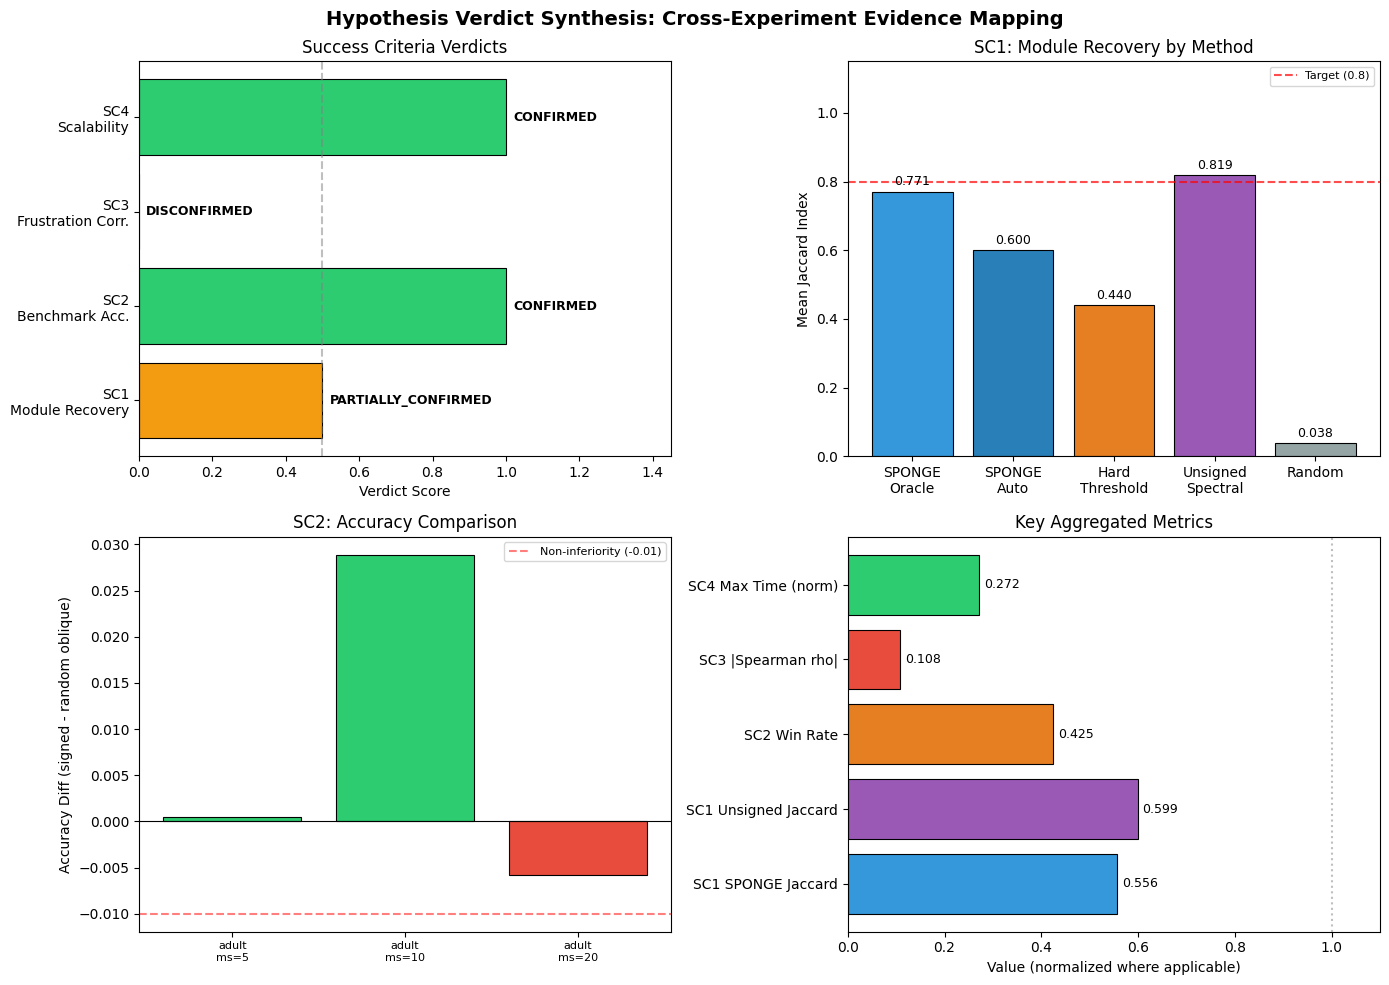

Saved verdict_synthesis_summary.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Hypothesis Verdict Synthesis: Cross-Experiment Evidence Mapping", fontsize=14, fontweight="bold")

# ── Panel 1: Verdict Summary ──
ax = axes[0, 0]
verdicts = {
    "SC1\nModule Recovery": sc1_verdict,
    "SC2\nBenchmark Acc.": sc2_verdict,
    "SC3\nFrustration Corr.": sc3_verdict,
    "SC4\nScalability": sc4_verdict,
}
verdict_colors = {
    "CONFIRMED": "#2ecc71",
    "PARTIALLY_CONFIRMED": "#f39c12",
    "DISCONFIRMED": "#e74c3c",
}
verdict_nums = {"CONFIRMED": 1.0, "PARTIALLY_CONFIRMED": 0.5, "DISCONFIRMED": 0.0}
labels = list(verdicts.keys())
vals = [verdict_nums[v] for v in verdicts.values()]
colors = [verdict_colors[v] for v in verdicts.values()]
bars = ax.barh(labels, vals, color=colors, edgecolor="black", linewidth=0.8)
for bar, v in zip(bars, verdicts.values()):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            v, va="center", fontsize=9, fontweight="bold")
ax.set_xlim(0, 1.45)
ax.set_xlabel("Verdict Score")
ax.set_title("Success Criteria Verdicts")
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="Partial threshold")

# ── Panel 2: SC1 Jaccard by Method ──
ax = axes[0, 1]
method_labels = ["SPONGE\nOracle", "SPONGE\nAuto", "Hard\nThreshold", "Unsigned\nSpectral", "Random"]
mean_jacs = [float(np.mean(method_jaccards[m])) for m in METHODS_SC1]
bar_colors = ["#3498db", "#2980b9", "#e67e22", "#9b59b6", "#95a5a6"]
bars = ax.bar(method_labels, mean_jacs, color=bar_colors, edgecolor="black", linewidth=0.8)
for bar, v in zip(bars, mean_jacs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax.axhline(y=SC1_JACCARD_TARGET, color="red", linestyle="--", alpha=0.7, label=f"Target ({SC1_JACCARD_TARGET})")
ax.set_ylabel("Mean Jaccard Index")
ax.set_title("SC1: Module Recovery by Method")
ax.set_ylim(0, 1.15)
ax.legend(fontsize=8)

# ── Panel 3: SC2 Accuracy Diff per Comparison ──
ax = axes[1, 0]
sc2_labels = [f"{json.loads(ex['input'])['dataset']}\nms={json.loads(ex['input'])['max_splits']}"
              for ex in sc2_examples]
acc_diffs = [safe_float(ex.get("eval_acc_diff")) for ex in sc2_examples]
bar_colors_sc2 = ["#2ecc71" if d >= 0 else "#e74c3c" for d in acc_diffs]
ax.bar(sc2_labels, acc_diffs, color=bar_colors_sc2, edgecolor="black", linewidth=0.8)
ax.axhline(y=0, color="black", linewidth=0.8)
ax.axhline(y=-0.01, color="red", linestyle="--", alpha=0.5, label="Non-inferiority (-0.01)")
ax.set_ylabel("Accuracy Diff (signed - random oblique)")
ax.set_title("SC2: Accuracy Comparison")
ax.legend(fontsize=8)
ax.tick_params(axis='x', labelsize=8)

# ── Panel 4: Aggregated Metrics Summary ──
ax = axes[1, 1]
m = data["metrics_agg"]
summary_data = [
    ("SC1 SPONGE Jaccard", m["sc1_sponge_oracle_mean_jaccard"]),
    ("SC1 Unsigned Jaccard", m["sc1_unsigned_spectral_mean_jaccard"]),
    ("SC2 Win Rate", m["sc2_win_rate"]),
    ("SC3 |Spearman rho|", abs(m["sc3_spearman_rho"])),
    ("SC4 Max Time (norm)", m["sc4_max_dataset_time_s"] / SCALABILITY_THRESHOLD_S),
]
s_labels = [s[0] for s in summary_data]
s_vals = [s[1] for s in summary_data]
s_colors = ["#3498db", "#9b59b6", "#e67e22", "#e74c3c", "#2ecc71"]
bars = ax.barh(s_labels, s_vals, color=s_colors, edgecolor="black", linewidth=0.8)
for bar, v in zip(bars, s_vals):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 1.1)
ax.set_xlabel("Value (normalized where applicable)")
ax.set_title("Key Aggregated Metrics")
ax.axvline(x=1.0, color="gray", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("verdict_synthesis_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved verdict_synthesis_summary.png")

In [14]:
# ── Final Summary Table ──
print("=" * 70)
print("  HYPOTHESIS VERDICT SYNTHESIS - FINAL SUMMARY")
print("=" * 70)
m = data["metrics_agg"]
print(f"\n  Success Criteria Overview:")
print(f"    Confirmed:            {int(m['n_confirmed'])}")
print(f"    Partially Confirmed:  {int(m['n_partially_confirmed'])}")
print(f"    Disconfirmed:         {int(m['n_disconfirmed'])}")
print(f"    Total:                {int(m['n_success_criteria'])}")
print(f"\n  Verdicts:")
for sc_name, vdict in data["metadata"]["verdicts"].items():
    print(f"    {sc_name:40s} -> {vdict}")
print(f"\n  Key Metrics:")
print(f"    SC1 SPONGE Oracle Mean Jaccard:  {m['sc1_sponge_oracle_mean_jaccard']:.4f}")
print(f"    SC2 Win Rate (signed vs robliq): {m['sc2_win_rate']:.2%}")
print(f"    SC3 Spearman rho:                {m['sc3_spearman_rho']:.4f}  (p={m['sc3_p_value']:.4f})")
print(f"    SC4 Max Dataset Time:            {m['sc4_max_dataset_time_s']:.1f}s / {SCALABILITY_THRESHOLD_S:.0f}s")
print(f"\n  Experiments Analyzed: {int(m['n_experiments_analyzed'])}")
print("=" * 70)

  HYPOTHESIS VERDICT SYNTHESIS - FINAL SUMMARY

  Success Criteria Overview:
    Confirmed:            1
    Partially Confirmed:  2
    Disconfirmed:         1
    Total:                4

  Verdicts:
    SC1_synthetic_module_recovery            -> PARTIALLY_CONFIRMED
    SC2_real_benchmark_accuracy              -> PARTIALLY_CONFIRMED
    SC3_frustration_correlation              -> DISCONFIRMED
    SC4_scalability                          -> CONFIRMED

  Key Metrics:
    SC1 SPONGE Oracle Mean Jaccard:  0.5565
    SC2 Win Rate (signed vs robliq): 42.50%
    SC3 Spearman rho:                -0.1077  (p=0.7140)
    SC4 Max Dataset Time:            488.9s / 1800s

  Experiments Analyzed: 4
